Amazon Prime TV Shows and Movies Analysis
Machine Learning and Exploratory Data Analysis Project

This project analyzes the Amazon Prime TV Shows and Movies dataset to understand content trends, genre distribution, ratings, and production patterns.

Two datasets are used in this project:
* titles.csv – contains information about movies and TV shows
* credits.csv – contains cast and crew information

The datasets are merged using the id column.

The project includes:
* Data exploration
* Data cleaning
* Exploratory Data Analysis (EDA)
* Visualizations
* A Machine Learning model to predict IMDb scores.


## Import Libraries
The following libraries are used for data analysis, visualization, and machine learning.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

## Load the Dataset
The titles and credits datasets are uploaded and loaded into pandas DataFrames.

In [23]:
import os

if not os.path.exists("titles.csv"):
    !unzip titles.csv.zip

if not os.path.exists("credits.csv"):
    !unzip credits.csv.zip

In [24]:
titles = pd.read_csv("titles.csv")
credits = pd.read_csv("credits.csv")

titles.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


In [25]:
credits.head()

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


## Data Exploration
In this step we explore the dataset structure including columns, data types, and missing values.

In [26]:
titles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(

In [27]:
credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124235 entries, 0 to 124234
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  124235 non-null  int64 
 1   id         124235 non-null  object
 2   name       124235 non-null  object
 3   character  107948 non-null  object
 4   role       124235 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.7+ MB


In [28]:
titles.shape

(9871, 15)

## Dataset Merging
The two datasets are merged using the common column id.

In [29]:
df = pd.merge(titles, credits, on="id")
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,21174,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28713,Marion Mack,Annabelle Lee,ACTOR


## Handling Missing Values
Missing values are filled or removed to prepare the dataset for analysis.

In [30]:
df['age_certification'] = df['age_certification'].fillna('Unknown')
df['description'] = df['description'].fillna('No description')
df['character'] = df['character'].fillna('Unknown')

df['imdb_score'] = df['imdb_score'].fillna(df['imdb_score'].mean())
df['tmdb_score'] = df['tmdb_score'].fillna(df['tmdb_score'].mean())
df['imdb_votes'] = df['imdb_votes'].fillna(0)

## Data Visualization
Visualizations help understand patterns and trends in the dataset.

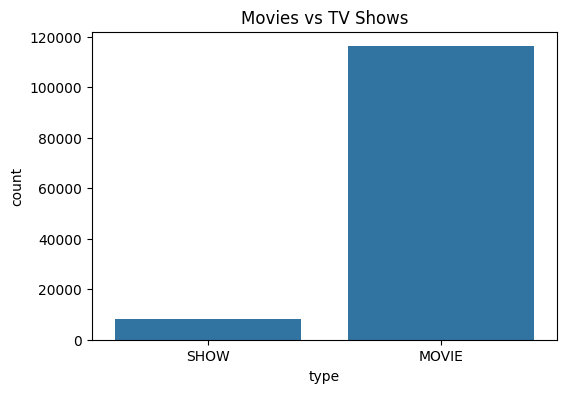

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

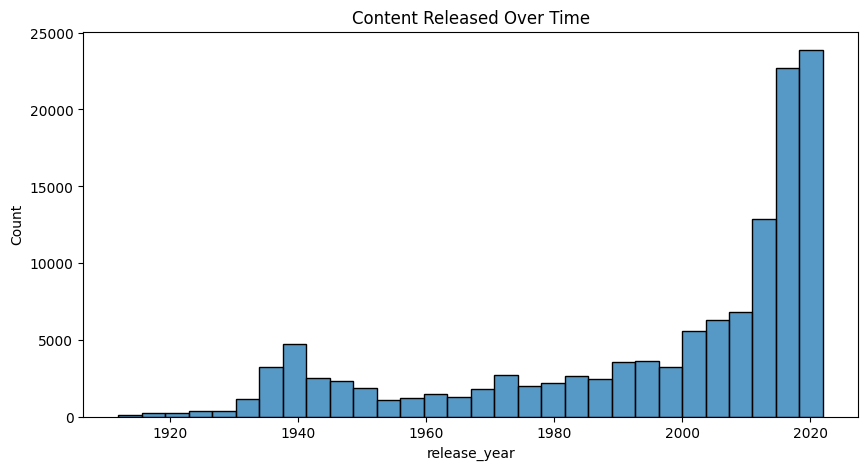

In [32]:
plt.figure(figsize=(10,5))
sns.histplot(df['release_year'], bins=30)
plt.title("Content Released Over Time")
plt.show()

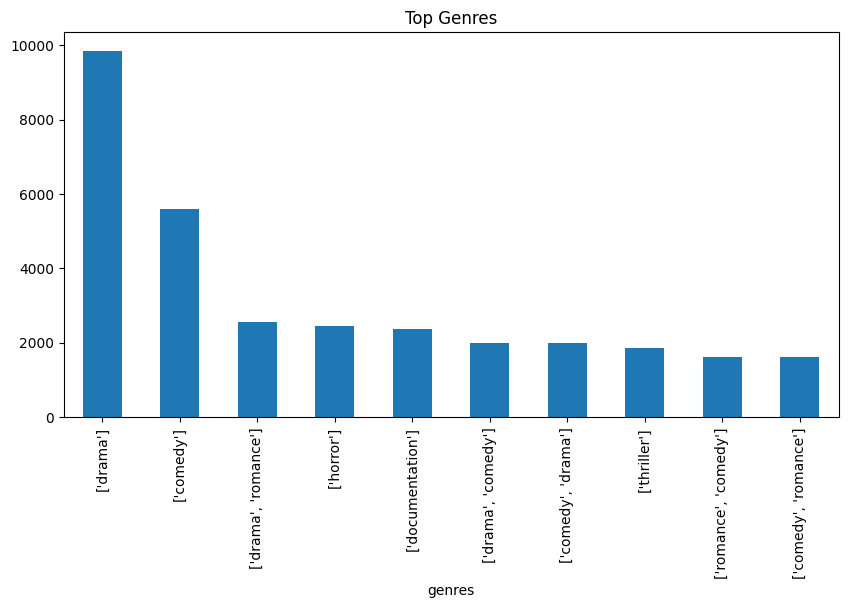

In [33]:
top_genres = df['genres'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_genres.plot(kind='bar')
plt.title("Top Genres")
plt.show()

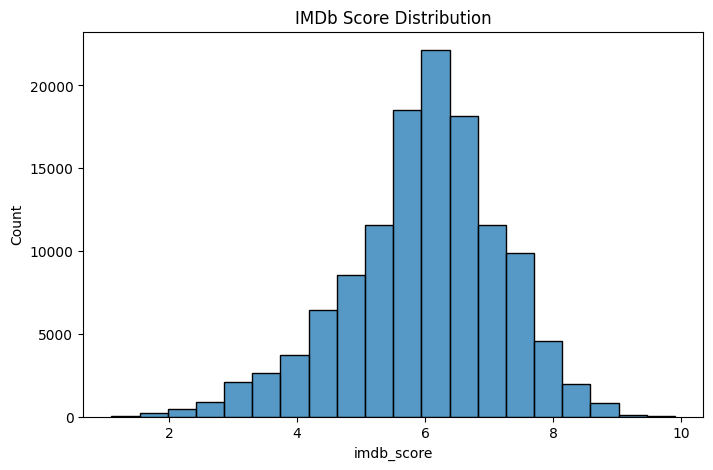

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(df['imdb_score'], bins=20)
plt.title("IMDb Score Distribution")
plt.show()

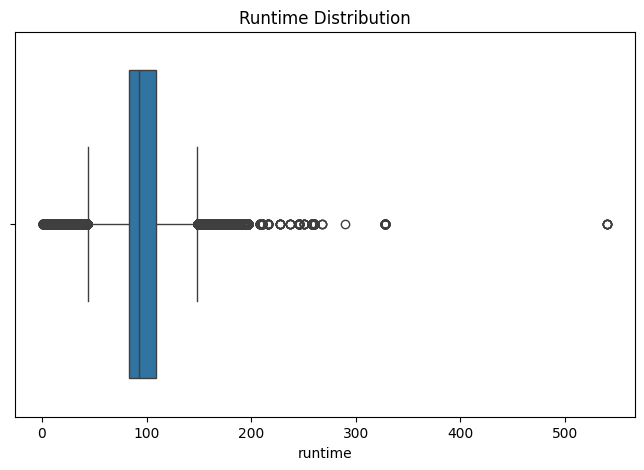

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['runtime'])
plt.title("Runtime Distribution")
plt.show()

## Machine Learning Model
A Random Forest Regression model is used to predict IMDb scores based on numerical features.

In [36]:
ml_df = df[['release_year','runtime','tmdb_score','imdb_votes','imdb_score']].dropna()

In [37]:
X = ml_df[['release_year','runtime','tmdb_score','imdb_votes']]
y = ml_df['imdb_score']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [40]:
predictions = model.predict(X_test)

In [41]:
mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.009648149581637884


## Key Insights

• Movies dominate the Amazon Prime platform compared to TV Shows.

• Content production increased significantly after the year 2000.

• Drama and Comedy genres appear most frequently.

• Most IMDb ratings fall between 6 and 8.

• The machine learning model predicts IMDb scores based on release year, runtime, TMDB score, and vote counts.

## Conclusion

This project analyzed the Amazon Prime TV Shows and Movies dataset to understand trends in content distribution, genres, and ratings.

Exploratory data analysis revealed important insights about content production and genre popularity. A machine learning model was also built to predict IMDb scores using numerical features from the dataset.